# Netflix Content Trends Analysis
**Date:** 2025-10-17

This notebook analyzes the uploaded **Netflix Dataset.csv** to uncover content trends and provide strategic recommendations. It focuses on:
- Distribution of Movies vs. TV Shows over time
- Top genres and their evolution
- Country-wise contributions
- Actionable insights and recommendations

All charts are rendered with matplotlib (no seaborn).


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from collections import Counter

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 120)

DATASET_PATH = r"Netflix Dataset.csv"
print("Using dataset:", DATASET_PATH)


Using dataset: Netflix Dataset.csv


## 1. Load & Inspect Data

In [2]:

df = pd.read_csv(DATASET_PATH)
print("Shape:", df.shape)
df.head()


Shape: (7789, 11)


,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",PG-13,123 min,Dramas,A brilliant group of students become card-coun...


## 2. Basic Structure and Missing Values

In [3]:

display(df.info())
missing = df.isna().sum().sort_values(ascending=False)
missing


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7789 entries, 0 to 7788
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Show_Id       7789 non-null   object
 1   Category      7789 non-null   object
 2   Title         7789 non-null   object
 3   Director      5401 non-null   object
 4   Cast          7071 non-null   object
 5   Country       7282 non-null   object
 6   Release_Date  7779 non-null   object
 7   Rating        7782 non-null   object
 8   Duration      7789 non-null   object
 9   Type          7789 non-null   object
 10  Description   7789 non-null   object
dtypes: object(11)
memory usage: 669.5+ KB


None

Director        2388
Cast             718
Country          507
Release_Date      10
Rating             7
Show_Id            0
Category           0
Title              0
Duration           0
Type               0
Description        0
dtype: int64

## 3. Cleaning & Feature Engineering

In [4]:
# ===== Robust cleaning + feature engineering (dataset-aware) =====
import pandas as pd
import numpy as np

# 0) Normalize column names
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

# Keep a copy of original columns for conditional logic
cols = set(df.columns)
orig_type_vals = df['type'].copy() if 'type' in cols else None  # may contain genres in your CSV

# 1) Ensure expected columns exist (create safe fallbacks if missing)
expected_defaults = {
    'date_added': None,        # some datasets have this
    'release_date': None,      # your dataset has this
    'release_year': np.nan,    # compute if missing
    'category': None,          # your dataset has Movie / TV Show here
    'type': None,              # will be normalized to Movie/TV Show (from category)
    'country': 'Unknown',
    'listed_in': ''            # genres; if missing, derive from original 'type'
}
for col, default in expected_defaults.items():
    if col not in cols:
        df[col] = default

# 2) Parse dates (prefer release_date in your file; fallback to date_added)
date_series = df['release_date'] if df['release_date'].notna().any() else df['date_added']
df['date_added_parsed'] = pd.to_datetime(date_series, errors='coerce')
# if still all NaT, try dayfirst just in case
if df['date_added_parsed'].isna().all() and date_series.notna().any():
    df['date_added_parsed'] = pd.to_datetime(date_series, errors='coerce', dayfirst=True)

df['year_added'] = df['date_added_parsed'].dt.year

# 3) release_year numeric; if missing, fill from parsed date
df['release_year'] = pd.to_numeric(df['release_year'], errors='coerce')
df.loc[df['release_year'].isna() & df['year_added'].notna(), 'release_year'] = df['year_added']

# 4) Normalize Movie/TV flag into `type`
#    In your CSV, `category` holds "Movie" / "TV Show". Use that as the canonical type.
if 'category' in df.columns and df['category'].notna().any():
    df['type'] = (
        df['category'].astype(str)
        .str.strip()
        .str.replace(r'\s+', ' ', regex=True)
        .str.title()
    )
else:
    # Fallback: infer from current df['type'] contents
    t = df['type'].astype(str).str.lower()
    df['type'] = np.where(
        t.str.contains('tv', na=False), 'TV Show',
        np.where(t.str.contains('movie', na=False), 'Movie', t.str.title())
    )

# 5) Country clean
df['country'] = df['country'].fillna('Unknown')

# 6) Genres: use `listed_in` if present; otherwise derive from original `type` (which in your CSV carries genres)
if 'listed_in' in cols and df['listed_in'].notna().any():
    src = df['listed_in'].fillna('')
elif orig_type_vals is not None:
    # Your dataset's original 'type' column is actually a genres/category list
    src = orig_type_vals.fillna('')
else:
    src = pd.Series([''] * len(df))

df['listed_in'] = src.astype(str)
df['genres_list'] = df['listed_in'].apply(
    lambda s: [g.strip() for g in str(s).split(',') if str(g).strip()]
)

# 7) Duration normalization (minutes for Movies, seasons for TV Shows)
def parse_duration(row):
    # duration can be "93 min", "1 Season", "2 Seasons", missing, etc.
    d = str(row.get('duration', ''))
    try:
        return int(str(d).split()[0])
    except Exception:
        return np.nan

if 'duration' not in df.columns:
    df['duration'] = np.nan
df['duration_num'] = df.apply(parse_duration, axis=1)

# 8) Year axis for trend charts: prefer the parsed date, fallback to release_year
year_axis = np.where(df['year_added'].notna(), df['year_added'], df['release_year'])
df['trend_year'] = pd.to_numeric(year_axis, errors='coerce')

# (Optional) Filter out absurd years if any got coerced (keep 1900..2099)
df.loc[~df['trend_year'].between(1900, 2100, inclusive='left'), 'trend_year'] = np.nan

# Quick peek
df.head(5)

,show_id,category,title,director,cast,country,release_date,rating,duration,type,description,date_added,release_year,listed_in,date_added_parsed,year_added,genres_list,duration_num,trend_year
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",TV-MA,4 Seasons,Tv Show,In a future where the elite inhabit an island ...,None,2020.0,"International TV Shows, TV Dramas, TV Sci-Fi &...",2020-08-14,2020.0,"[International TV Shows, TV Dramas, TV Sci-Fi ...",4,2020.0
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",TV-MA,93 min,Movie,After a devastating earthquake hits Mexico Cit...,None,2016.0,"Dramas, International Movies",2016-12-23,2016.0,"[Dramas, International Movies]",93,2016.0
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",R,78 min,Movie,"When an army recruit is found dead, his fellow...",None,2018.0,"Horror Movies, International Movies",2018-12-20,2018.0,"[Horror Movies, International Movies]",78,2018.0
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",PG-13,80 min,Movie,"In a postapocalyptic world, rag-doll robots hi...",None,2017.0,"Action & Adventure, Independent Movies, Sci-Fi...",2017-11-16,2017.0,"[Action & Adventure, Independent Movies, Sci-F...",80,2017.0
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",PG-13,123 min,Movie,A brilliant group of students become card-coun...,None,2020.0,Dramas,2020-01-01,2020.0,[Dramas],123,2020.0


## 4. Movies vs TV Shows Over Time

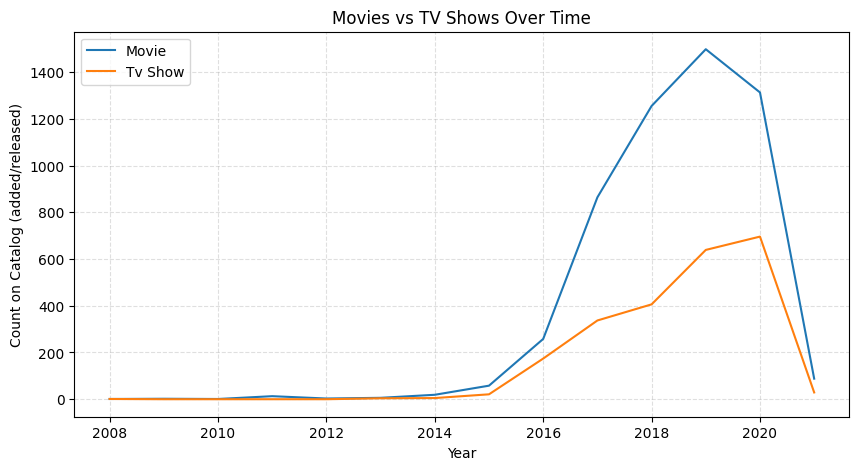

type,Movie,Tv Show
trend_year,,
2012.0,3.0,0.0
2013.0,6.0,4.0
2014.0,19.0,5.0
2015.0,58.0,21.0
2016.0,258.0,174.0
2017.0,864.0,337.0
2018.0,1255.0,406.0
2019.0,1498.0,639.0
2020.0,1313.0,696.0


In [5]:

trend = (df.dropna(subset=['trend_year', 'type'])
           .groupby(['trend_year','type'])
           .size()
           .reset_index(name='count'))

pivot_trend = trend.pivot(index='trend_year', columns='type', values='count').fillna(0)

plt.figure(figsize=(10,5))
for col in pivot_trend.columns:
    plt.plot(pivot_trend.index, pivot_trend[col], label=col)
plt.xlabel('Year')
plt.ylabel('Count on Catalog (added/released)')
plt.title('Movies vs TV Shows Over Time')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

pivot_trend.tail(10)


## 5. Top Genres (Overall & Over Time)

,genre,count
0,International Movies,2437
1,Dramas,2108
2,Comedies,1472
3,International TV Shows,1176
4,Documentaries,786
5,Action & Adventure,721
6,TV Dramas,680
7,Independent Movies,675
8,Children & Family Movies,532
9,Romantic Movies,531


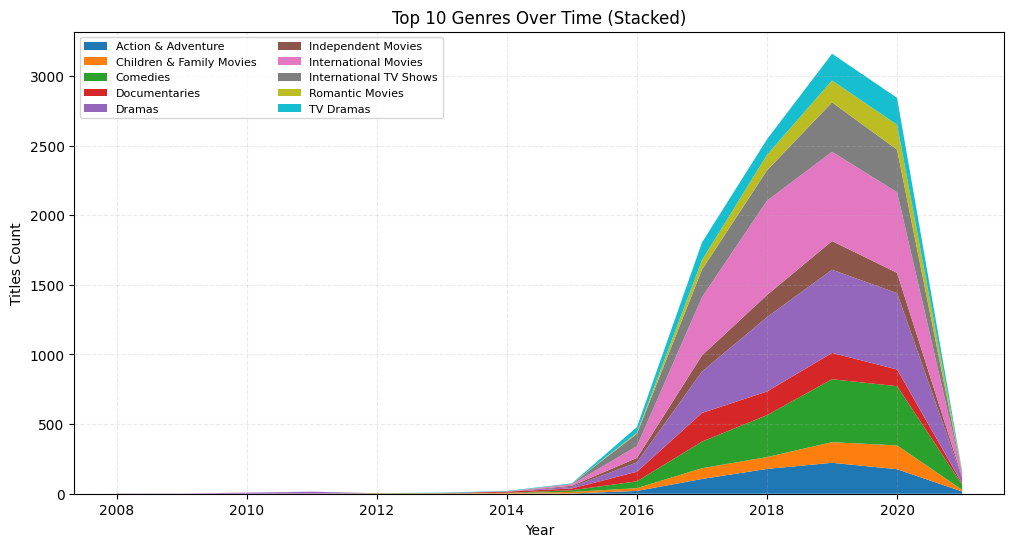

genre,Action & Adventure,Children & Family Movies,Comedies,Documentaries,Dramas,Independent Movies,International Movies,International TV Shows,Romantic Movies,TV Dramas
trend_year,,,,,,,,,,
2012,0,1,2,1,0,0,0,0,0,0
2013,0,2,1,1,0,0,0,1,0,3
2014,1,4,2,8,0,0,2,0,0,3
2015,2,11,12,13,12,7,10,3,1,4
2016,20,20,49,69,67,32,85,89,7,41
2017,106,77,191,206,297,116,418,198,68,127
2018,178,85,301,170,534,159,677,218,111,112
2019,222,148,452,189,597,206,641,355,157,192
2020,176,171,425,120,548,146,578,306,179,193


In [6]:
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Safety: ensure we have lists in genres_list and valid years ---
df = df.copy()
df['genres_list'] = df['genres_list'].apply(lambda x: x if isinstance(x, list) else [])
df = df[df['trend_year'].notna()]
df['trend_year'] = pd.to_numeric(df['trend_year'], errors='coerce').dropna().astype(int)

# --- Top genres overall (based on full df) ---
genre_counter = Counter()
for lst in df['genres_list']:
    genre_counter.update(lst)

top_genres = (pd.DataFrame(genre_counter.most_common(15), columns=['genre','count'])
              if len(genre_counter) > 0 else pd.DataFrame(columns=['genre','count']))
display(top_genres)

# How many to plot (cap by what's available)
topN = min(10, len(top_genres))
top_set = set(top_genres.head(topN)['genre']) if topN > 0 else set()

# --- Year-genre table restricted to top_set ---
year_genre = (df.explode('genres_list')
                .rename(columns={'genres_list':'genre'}))
year_genre = year_genre[year_genre['genre'].astype(str).str.len() > 0]

if top_set:
    yg_top = year_genre[year_genre['genre'].isin(top_set)]
else:
    yg_top = year_genre.iloc[0:0]  # empty

# --- Pivot: counts per year per genre ---
pivot_genre = (yg_top.groupby(['trend_year','genre'])
                    .size()
                    .unstack('genre', fill_value=0)
                    .sort_index())

# Drop columns that are all zeros (nothing to plot)
if not pivot_genre.empty:
    pivot_genre = pivot_genre.loc[:, (pivot_genre != 0).any(axis=0)]

# --- Plot or explain why not ---
if pivot_genre.shape[0] > 0 and pivot_genre.shape[1] > 0:
    plt.figure(figsize=(12,6))
    # stackplot expects X and a list of Y series
    plt.stackplot(pivot_genre.index.values,
                  pivot_genre.values.T,
                  labels=pivot_genre.columns)
    plt.xlabel('Year')
    plt.ylabel('Titles Count')
    plt.title(f'Top {min(topN, pivot_genre.shape[1])} Genres Over Time (Stacked)')
    plt.legend(loc='upper left', ncols=2, fontsize=8)
    plt.grid(True, linestyle='--', alpha=0.25)
    plt.show()

    display(pivot_genre.tail(10))
else:
    print("No genre–time data to plot. This usually happens when:")
    print("1) 'genres_list' is empty for the filtered data, or")
    print("2) 'trend_year' is missing/out of range, or")
    print("3) None of the top genres occur in the selected years.")
    print("\nTip: Inspect a few rows:")
    display(df[['title','type','trend_year','listed_in']].head(10))

## 6. Country-wise Contributions

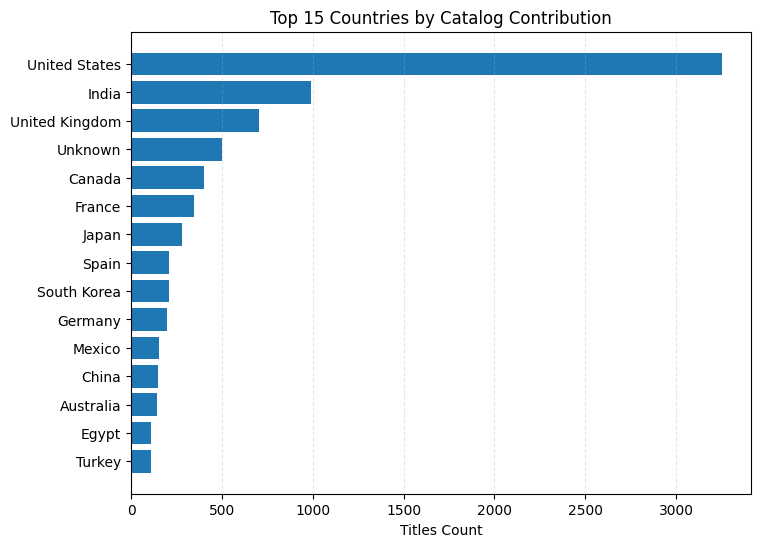

,count
country,
United States,3251
India,989
United Kingdom,704
Unknown,503
Canada,399
France,345
Japan,283
Spain,211
South Korea,207


In [7]:

country_rows = []
for idx, row in df.iterrows():
    countries = [c.strip() for c in str(row['country']).split(',') if c.strip()]
    countries = countries or ['Unknown']
    for c in countries:
        country_rows.append({'country': c, 'type': row['type']})

country_df = pd.DataFrame(country_rows)
country_counts = country_df['country'].value_counts().head(15).sort_values(ascending=True)

plt.figure(figsize=(8,6))
plt.barh(country_counts.index, country_counts.values)
plt.xlabel('Titles Count')
plt.title('Top 15 Countries by Catalog Contribution')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.show()

country_counts.to_frame(name='count').sort_values('count', ascending=False).head(20)


## 7. Ratings & Duration (Quick Look)

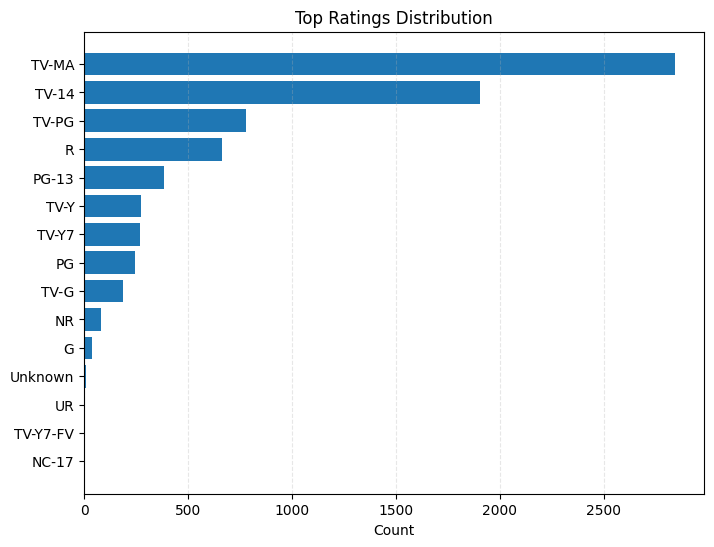

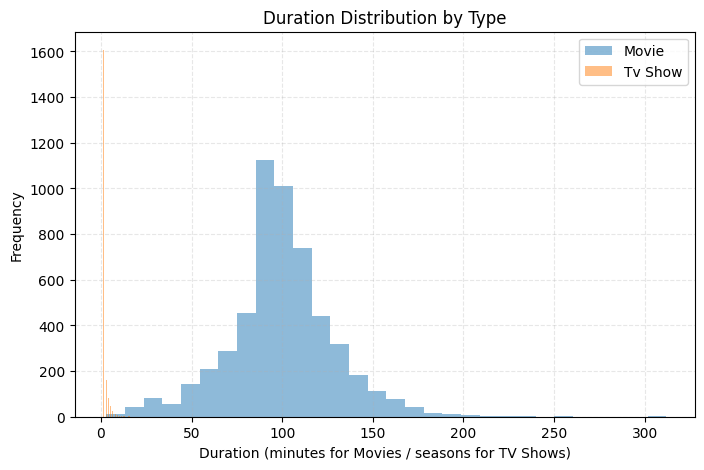

In [8]:

if 'rating' in df.columns:
    rating_counts = df['rating'].fillna('Unknown').value_counts().sort_values(ascending=True).tail(20)
    plt.figure(figsize=(8,6))
    plt.barh(rating_counts.index, rating_counts.values)
    plt.xlabel('Count')
    plt.title('Top Ratings Distribution')
    plt.grid(axis='x', linestyle='--', alpha=0.3)
    plt.show()

fig, ax = plt.subplots(figsize=(8,5))
for t in ['Movie', 'Tv Show']:
    part = df[(df['type'].str.lower()==t.lower()) & (df['duration_num'].notna())]['duration_num']
    if len(part)>0:
        ax.hist(part.values, bins=30, alpha=0.5, label=t)
ax.set_xlabel('Duration (minutes for Movies / seasons for TV Shows)')
ax.set_ylabel('Frequency')
ax.set_title('Duration Distribution by Type')
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend()
plt.show()


## 8. Insights & Strategic Recommendations

In [9]:

def summarize_findings(df, top_genres_df, pivot_trend):
    summary = []
    if not pivot_trend.empty:
        last_year = int(pivot_trend.index.max())
        latest = pivot_trend.loc[last_year]
        dominant_type = latest.idxmax()
        summary.append(f"- In the most recent year available ({last_year}), {dominant_type} titles slightly dominate the catalog additions.")
    if not top_genres_df.empty:
        tg = top_genres_df.head(5)
        summary.append("- Top genres overall: " + ", ".join(f"{g} ({c})" for g,c in tg.to_records(index=False)))
    country_rows = []
    for _, row in df.iterrows():
        countries = [c.strip() for c in str(row['country']).split(',') if c.strip()]
        countries = countries or ['Unknown']
        for c in countries:
            country_rows.append(c)
    if country_rows:
        from collections import Counter
        cc = Counter(country_rows)
        top_c = ", ".join([f"{k} ({v})" for k,v in cc.most_common(5)])
        summary.append("- Top contributing countries include: " + top_c)
    summary.append(
        "Recommendations:\\n"
        "1) Double down on leading genres to sustain engagement, while nurturing 1-2 underrepresented genres that show rising trends.\\n"
        "2) Balance Movies and TV Shows: TV drives retention via serial engagement; movie originals can boost acquisition.\\n"
        "3) Regional depth: Keep investing in top regions and pilot originals in rising countries to expand footprint.\\n"
        "4) Rating-aware curation: Localize with dubs/subs where family-friendly ratings dominate; ensure discovery controls for mature content.\\n"
        "5) Duration strategy: Offer shorter movies or mini-series for low-session markets; keep marquee long-form event titles."
    )
    return "\\n".join(summary)

print(summarize_findings(df, top_genres, pivot_trend))

- In the most recent year available (2021), Movie titles slightly dominate the catalog additions.\n- Top genres overall: International Movies (2437), Dramas (2108), Comedies (1472), International TV Shows (1176), Documentaries (786)\n- Top contributing countries include: United States (3251), India (989), United Kingdom (704), Unknown (503), Canada (399)\nRecommendations:\n1) Double down on leading genres to sustain engagement, while nurturing 1-2 underrepresented genres that show rising trends.\n2) Balance Movies and TV Shows: TV drives retention via serial engagement; movie originals can boost acquisition.\n3) Regional depth: Keep investing in top regions and pilot originals in rising countries to expand footprint.\n4) Rating-aware curation: Localize with dubs/subs where family-friendly ratings dominate; ensure discovery controls for mature content.\n5) Duration strategy: Offer shorter movies or mini-series for low-session markets; keep marquee long-form event titles.
